<a href="https://colab.research.google.com/github/faat-prasojo/Pembelajaran_Mesin_2026/blob/main/Pertemuan%2004/Tugas_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas K-Means

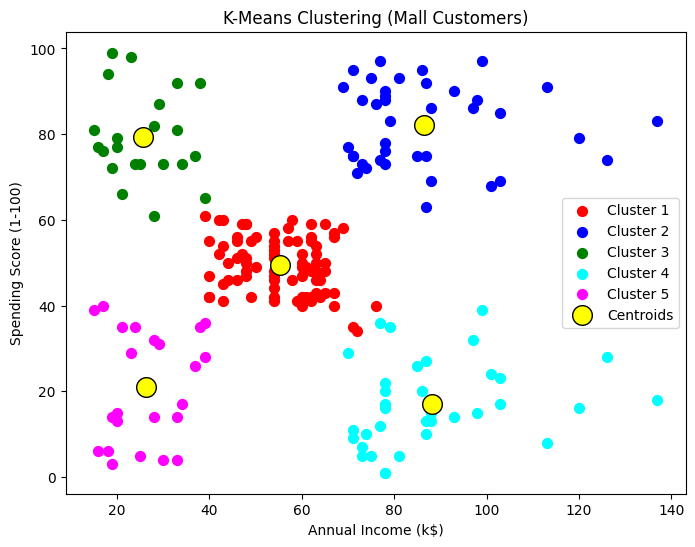

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Load Data
df = pd.read_csv('Mall_Customers.csv')

# 2. Pilih Fitur
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# 3. Mencari k terbaik dengan Elbow Method & Silhouette Score
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# 4. Modeling dengan k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# 5. Visualisasi Hasil Klasterisasi
plt.figure(figsize=(8, 6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=50, c='magenta', label='Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', edgecolors='black', label='Centroids')

plt.title('K-Means Clustering (Mall Customers)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Tugas DBSCAN

Jumlah Klaster: 2
Jumlah Noise: 0

=== Evaluasi Metrik ===
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index (ARI): 1.000
Adjusted Mutual Info (AMI): 1.000
Silhouette Coefficient: 0.391



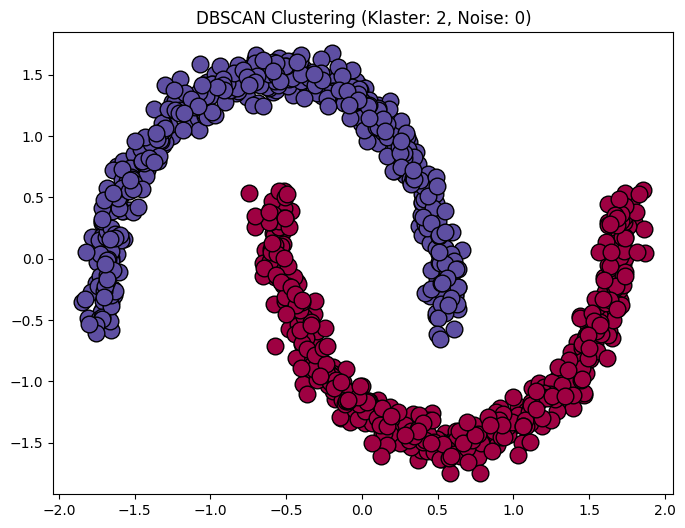

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Buat dataset make_moons & normalisasi
X_m, y_m = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_m_scaled = StandardScaler().fit_transform(X_m)

# 2. Jalankan DBSCAN (eps=0.2, min_samples=5)
db = DBSCAN(eps=0.2, min_samples=5).fit(X_m_scaled)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Jumlah Klaster: {n_clusters_}")
print(f"Jumlah Noise: {n_noise_}\n")

# 3. Evaluasi Metrik
print("=== Evaluasi Metrik ===")
print(f"Homogeneity: {metrics.homogeneity_score(y_m, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_m, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_m, labels):.3f}")
print(f"Adjusted Rand Index (ARI): {metrics.adjusted_rand_score(y_m, labels):.3f}")
print(f"Adjusted Mutual Info (AMI): {metrics.adjusted_mutual_info_score(y_m, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_m_scaled, labels):.3f}\n")

# 4. Visualisasi Hasil DBSCAN
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Hitam untuk Noise

    class_member_mask = labels == k

    # Core sample = titik besar
    xy = X_m_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=12)

    # Non-core sample = titik kecil
    xy = X_m_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=5)

plt.title(f"DBSCAN Clustering (Klaster: {n_clusters_}, Noise: {n_noise_})")
plt.show()